# 32: the forecasting comparison

Twelve series, eight measured and four generated from a known governing equation, forecast
forward from a training window. Claims:

1. Fitting the structure a series is declared with (`study.forecasting.fit_kind`) beats
   `dtfit.auto_forecast`'s blind structure search by a wide margin on every series whose
   governing equation is known, and stays close to it elsewhere: on the eight measured series
   the blind route matches the declared structure on two and beats it on two. False if the
   margin on any of the four generated waveforms falls under 5x, if the blind route wins on
   one of those four, or if the series it matches or beats are other than the four the
   "Who wins where" check cell names.
2. The declared structure is not free: fitting a series with the wrong structure (a negative
   control) is worse than fitting it with the right one, in both curve error and in-sample R2.
   False if the wrong structure ever wins or its R2 does not flag it.
3. Random-walk persistence is a real baseline, not a strawman: the declared structure loses
   to it outright on USD/UAH, a series closer to a random walk than to any of the candidate
   structures. False if that loss disappears.
4. Against the published long-term-forecasting benchmark (DLinear, TimesNet, Time-LLM), the
   trend-plus-seasonal forecaster written inline under "The LTSF protocol against published
   numbers" is not competitive: its MSE stays at least 2x the best published number at the
   96-step horizon, on every one of the three benchmark sets tried. It is also worse than
   repeating the last observed value, the anchor it is built on, so what the gap bounds is
   that heuristic and not the library: the section calls nothing from dtfit. False if it
   ever comes within 2x of the published number, or if it beats its own repeat-last anchor.
5. On real hourly traffic sensors, an image fit, that same fit polished by a pointwise solve,
   and a plain pointwise fit from the same seed converge to the same forecast: the image is
   not a weaker estimator here, it is the same optimum reached a different way. False if the
   image median sits more than 5 percent from the polished/NLLS median, or either median
   falls outside 8 to 12 percent of the nine-day window's range.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import sympy as sp
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import dtfit as dt
from dtfit_experimental.study import series, forecasting as F, datasets as ds, notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

#: The declared-structure fits run at the spectral order their seed builds, and dtfit warns
#: once per fit that the order does not cover the model's sensitivities.
warnings.filterwarnings("ignore", message="image coverage")
notebook.plain_warnings()

#: The four series with a known governing equation, used alone under QUICK: they need no
#: file on disk and stay fast, and they are also the set the margin-over-auto_forecast claim
#: is about.
GENERATED = ["RLC transient", "AC + harmonics", "AM signal", "Linear chirp"]
CHOSEN = set(GENERATED) if QUICK else {name for name, *_ in series.SERIES}
print(f"QUICK={QUICK} series considered={len(CHOSEN)}")


def nrmse(pred, truth):
    # RMSE of `pred` against `truth`, as a percent of the truth's range.
    truth = np.asarray(truth, dtype=float)
    rng = float(np.max(truth) - np.min(truth)) or 1.0
    return float(np.sqrt(np.mean((np.asarray(pred, dtype=float) - truth) ** 2))) / rng * 100.0

QUICK=False series considered=12


## The twelve series

Eight are measured -- two from a tracked CSV, four bundled with `statsmodels`, two replayed
from the LTSF benchmark files -- and four are generated from a governing equation plus
measurement noise, each seeded so a rerun reproduces the same array. `study.series.SERIES`
carries the declared structure fitted in the sections below and the reason for it.

In [2]:
SOURCE = {
    "COVID-19 UA": "measured, data_dir()/covid_ukraine_confirmed.csv",
    "USD/UAH": "measured, data_dir()/usd_uah_2014_2015.csv",
    "Sunspots": "measured, statsmodels.datasets.sunspots",
    "Mauna Loa CO2": "measured, statsmodels.datasets.co2",
    "El Nino SST": "measured, statsmodels.datasets.elnino",
    "Nile flow": "measured, statsmodels.datasets.nile",
    "ETTh1 oil-temp": "measured, LTSF ETTh1.csv, replayed",
    "Weather LTSF": "measured, LTSF weather.csv, replayed",
    "RLC transient": "generated, damped oscillation equation, seeded",
    "AC + harmonics": "generated, fundamental + 3rd + 5th harmonic, seeded",
    "AM signal": "generated, amplitude-modulated carrier, seeded",
    "Linear chirp": "generated, linear frequency sweep, seeded",
}

DATA = {}
rows = []
for name, loader, kind, seasonal, period, why in series.SERIES:
    if name not in CHOSEN:
        continue
    y = loader()
    if y is None:
        print(f"data missing, dropping series: {name}")
        continue
    DATA[name] = {"y": y, "kind": kind, "seasonal": seasonal, "period": period}
    rows.append({"series": name, "source": SOURCE[name], "length": int(y.size),
                 "structure": kind, "why": why})
series_table = pd.DataFrame(rows)
series_table


,series,source,length,structure,why
0,COVID-19 UA,"measured, data_dir()/covid_ukraine_confirmed.csv",30,logistic,epidemic growth
1,USD/UAH,"measured, data_dir()/usd_uah_2014_2015.csv",730,linear_wave,currency depreciation
2,Sunspots,"measured, statsmodels.datasets.sunspots",309,sine,solar ~11y cycle
3,Mauna Loa CO2,"measured, statsmodels.datasets.co2",571,poly_seasonal,climate trend+season
4,El Nino SST,"measured, statsmodels.datasets.elnino",732,linear_seasonal,ocean seasonal
5,Nile flow,"measured, statsmodels.datasets.nile",100,poly,hydrology level
6,ETTh1 oil-temp,"measured, LTSF ETTh1.csv, replayed",1500,linear_seasonal,transformer temp
7,Weather LTSF,"measured, LTSF weather.csv, replayed",1500,transient_seasonal,weather sensor
8,RLC transient,"generated, damped oscillation equation, seeded",360,damped,physics: electrical ring-down
9,AC + harmonics,"generated, fundamental + 3rd + 5th harmonic, s...",360,fourier_series,physics: power waveform


In [3]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "series", series_table)
    print("wrote experiments/results/32_forecasting/series.csv")


wrote experiments/results/32_forecasting/series.csv


## The long horizon, 25 percent holdout

Each series is split at 75 percent of its length. `study.forecasting.fit_kind` fits the
series' own declared structure on the training window and extrapolates; `dtfit.auto_forecast`
does the same fully blind, routing between a handful of model classes on the training data
alone; the established toolkit (`study.forecasting.baseline_preds`: random walk, drift,
polynomial extrapolation, seasonal naive, Holt-Winters ETS, Theta, (S)ARIMA, an MLP) runs
beside them. Every column is scored the same way: RMSE against the holdout, as a percent of
the holdout's own range, so the rows compare across series of very different scale. The
declared-structure fits run at the order their seed builds rather than at `order_for`, and
dtfit's coverage warning for that order is filtered in the setup cell.

In [4]:
def run_horizon(frac):
    rows, forecasts = [], {}
    for name, d in DATA.items():
        y, kind, seasonal, period = d["y"], d["kind"], d["seasonal"], d["period"]
        n = y.size
        n_tr = max(int(round(n * (1 - frac))), 5)
        h = n - n_tr
        if h < 2:
            print(f"holdout too short, dropping series: {name}")
            continue
        t_all = np.arange(n, dtype=float)
        t_tr, y_tr, y_ho = t_all[:n_tr], y[:n_tr], y[n_tr:]
        cfg = {"seasonal": seasonal, "period": period}

        pred_struct = F.fit_kind(kind, t_tr, y_tr, t_all, period)[n_tr:]
        rows.append({"series": name, "method": "structure given",
                     "nrmse": nrmse(pred_struct, y_ho)})

        fc_auto = dt.auto_forecast(t_tr, y_tr, h, period=period, seasonal=seasonal)
        pred_auto = np.asarray(fc_auto)
        rows.append({"series": name, "method": "auto_forecast",
                     "nrmse": nrmse(pred_auto, y_ho)})

        for bname, bpred in F.baseline_preds(y_tr, h, cfg, QUICK).items():
            rows.append({"series": name, "method": bname, "nrmse": nrmse(bpred, y_ho)})

        forecasts[name] = dict(t_tr=t_tr, y_tr=y_tr, t_all=t_all, y_ho=y_ho,
                                pred_struct=pred_struct, pred_auto=pred_auto,
                                auto_model=fc_auto.model_name)
    return pd.DataFrame(rows), forecasts


accuracy_long, forecasts_long = run_horizon(0.25)
accuracy_long.pivot(index="series", columns="method", values="nrmse").round(2)


torch not installed, skipping


method,ARIMA,ETS (Holt-Winters),MLP,SARIMA,Theta,auto_forecast,drift,poly extrap,random walk,seasonal naive,structure given
series,,,,,,,,,,,
AC + harmonics,41.93,3.97,2.05,NaN,4.44,13.37,41.33,77.24,41.17,3.19,2.28
AM signal,17.30,98.58,13.92,NaN,61.56,26.55,70.33,26.55,60.84,NaN,1.16
COVID-19 UA,37.31,34.47,56.39,NaN,53.75,2.95,34.99,13.78,72.75,NaN,2.95
ETTh1 oil-temp,21.49,18.24,854.83,NaN,19.28,38.37,22.40,17.88,22.35,19.09,15.71
El Nino SST,12.46,12.39,15.41,12.55,12.34,12.68,40.26,23.65,36.85,14.23,13.15
Linear chirp,66.93,82.08,50.51,NaN,49.73,36.97,52.34,36.97,48.28,NaN,1.44
Mauna Loa CO2,40.67,27.52,45.43,39.66,28.30,18.81,14.27,19.66,44.47,47.03,17.62
Nile flow,29.81,36.36,30.30,NaN,38.16,29.72,38.97,29.72,30.74,NaN,29.72
RLC transient,65.77,47.37,11.84,NaN,33.66,133.47,28.70,133.47,28.24,NaN,9.55


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "accuracy_long", accuracy_long)
    print("wrote experiments/results/32_forecasting/accuracy_long.csv")


wrote experiments/results/32_forecasting/accuracy_long.csv


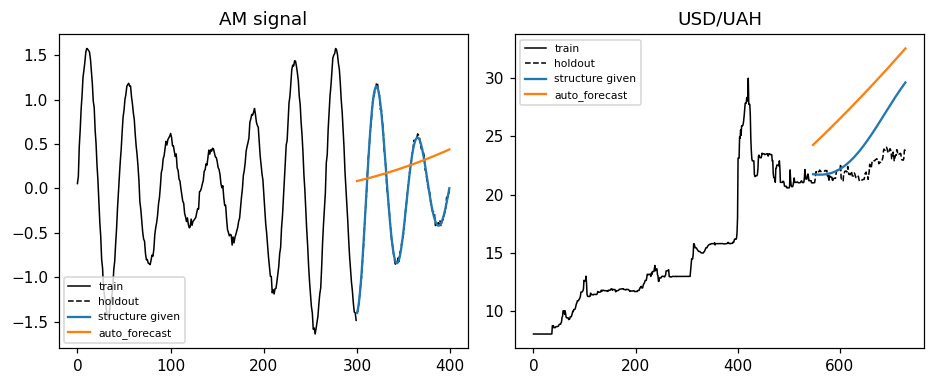

In [6]:
PANEL = [n for n in ("AM signal", "USD/UAH") if n in forecasts_long]
fig, axes = plt.subplots(1, len(PANEL), figsize=(8.6, 3.6))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, PANEL):
    fc = forecasts_long[name]
    ax.plot(fc["t_all"][:fc["t_tr"].size], fc["y_tr"], "k-", lw=1, label="train")
    ax.plot(fc["t_all"][fc["t_tr"].size:], fc["y_ho"], "k--", lw=1, label="holdout")
    ax.plot(fc["t_all"][fc["t_tr"].size:], fc["pred_struct"], "-", label="structure given")
    ax.plot(fc["t_all"][fc["t_tr"].size:], fc["pred_auto"], "-", label="auto_forecast")
    ax.set_title(name)
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


## The short horizon, 10 percent holdout

The same procedure, a shorter holdout: less of the record is left to extrapolate over, so
every method should read easier here than at the long horizon, structure or not.


In [7]:
accuracy_short, forecasts_short = run_horizon(0.10)
accuracy_short.pivot(index="series", columns="method", values="nrmse").round(2)


method,ARIMA,ETS (Holt-Winters),MLP,SARIMA,Theta,auto_forecast,drift,poly extrap,random walk,seasonal naive,structure given
series,,,,,,,,,,,
AC + harmonics,87.42,4.20,2.04,NaN,4.15,13.48,83.81,59.68,80.93,2.67,1.65
AM signal,6.11,150.70,11.38,NaN,48.83,36.62,51.48,36.62,49.57,NaN,3.09
COVID-19 UA,4.59,11.03,244.84,NaN,79.44,13.75,39.85,41.75,119.07,NaN,13.75
ETTh1 oil-temp,19.38,19.49,37.59,NaN,19.36,69.63,19.33,24.26,19.38,30.75,15.55
El Nino SST,17.68,20.14,20.41,22.90,21.70,13.48,28.43,28.86,28.42,14.34,14.21
Linear chirp,39.26,133.35,21.91,NaN,48.56,41.87,49.88,41.87,48.23,NaN,1.30
Mauna Loa CO2,33.46,65.53,9.17,22.97,26.80,131.54,20.53,19.09,38.12,42.60,9.99
Nile flow,32.17,32.49,34.13,NaN,30.17,35.44,34.07,35.44,33.54,NaN,35.44
RLC transient,76.61,57.21,19.44,NaN,24.54,175.95,23.38,175.95,23.09,NaN,37.37


In [8]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "accuracy_short", accuracy_short)
    print("wrote experiments/results/32_forecasting/accuracy_short.csv")


wrote experiments/results/32_forecasting/accuracy_short.csv


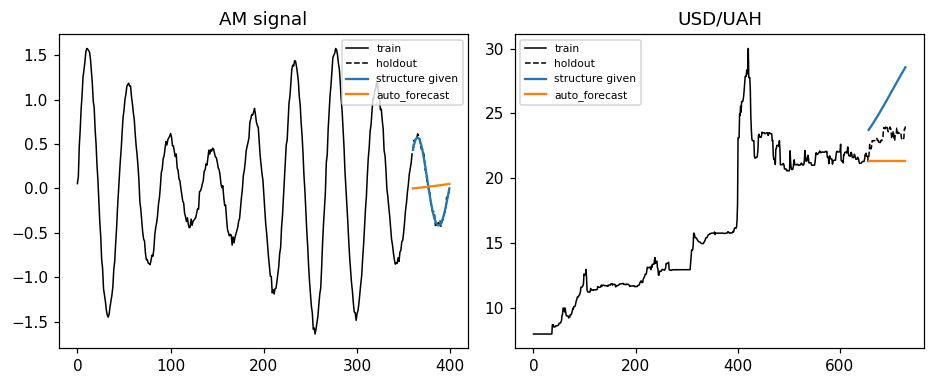

structure-given nRMSE, long vs short horizon:
                long (25%)  short (10%)
series                                 
COVID-19 UA       2.954143    13.752001
USD/UAH          94.229936   127.245054
Sunspots         35.101954    25.773941
Mauna Loa CO2    17.622994     9.994203
El Nino SST      13.146985    14.210605
Nile flow        29.722198    35.438262
ETTh1 oil-temp   15.707168    15.553976
Weather LTSF     77.947140    99.689102
RLC transient     9.548005    37.369616
AC + harmonics    2.280611     1.650114
AM signal         1.160264     3.086531
Linear chirp      1.441578     1.296040
the long holdout reads lower on 7 of 12: ['AM signal', 'COVID-19 UA', 'El Nino SST', 'Nile flow', 'RLC transient', 'USD/UAH', 'Weather LTSF']


In [9]:
PANEL = [n for n in ("AM signal", "USD/UAH") if n in forecasts_short]
fig, axes = plt.subplots(1, len(PANEL), figsize=(8.6, 3.6))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, PANEL):
    fc = forecasts_short[name]
    ax.plot(fc["t_all"][:fc["t_tr"].size], fc["y_tr"], "k-", lw=1, label="train")
    ax.plot(fc["t_all"][fc["t_tr"].size:], fc["y_ho"], "k--", lw=1, label="holdout")
    ax.plot(fc["t_all"][fc["t_tr"].size:], fc["pred_struct"], "-", label="structure given")
    ax.plot(fc["t_all"][fc["t_tr"].size:], fc["pred_auto"], "-", label="auto_forecast")
    ax.set_title(name)
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

struct_long = accuracy_long[accuracy_long.method == "structure given"].set_index("series").nrmse
struct_short = accuracy_short[accuracy_short.method == "structure given"].set_index("series").nrmse
common = struct_long.index.intersection(struct_short.index)
print("structure-given nRMSE, long vs short horizon:")
print(pd.DataFrame({"long (25%)": struct_long[common], "short (10%)": struct_short[common]}))
long_easier = sorted(common[struct_long[common] < struct_short[common]])
print(f"the long holdout reads lower on {len(long_easier)} of {len(common)}: {long_easier}")


The extrapolation-distance reading in the table above is not the clean "farther is harder"
ordering a first guess would expect: on seven of the twelve series the long (25 percent)
holdout reads as the easier one. nRMSE here is a percent of the holdout's own range, and a
short holdout can land on a quieter stretch whose range shrinks faster than the absolute
error does, inflating the percentage. The RLC transient is the clearest case: 9.5 percent at
the long horizon against 37.4 percent at the short one, because the last 10 percent of a
decayed ring-down has almost no amplitude left to normalize by. The other five show the
expected ordering, short easier than long: Sunspots, Mauna Loa CO2, the AC harmonics, the
chirp, and ETTh1 oil-temp by a hair, 15.55 against 15.71. This is a property of the
percent-of-holdout-range metric interacting with where a series' variance sits, not a
property of the method being compared.


## Who wins where

For every series, the method with the lowest long-horizon nRMSE. Named losses: the declared
structure loses to random-walk persistence only on USD/UAH, a currency crash and partial
recovery closer in shape to a random walk than to any of the candidate trend forms; the blind
`auto_forecast` route loses to random walk on four series -- USD/UAH, the RLC transient, ETTh1
oil-temp and the weather series -- where the class its routing picks cannot hold the shape of
the record. The blind route is not uniformly behind the declared structure either: it ties it to six
figures on COVID-19 UA and Nile flow and beats it on El Nino SST and Sunspots, four of the
twelve.

In [10]:
piv_long = accuracy_long.pivot(index="series", columns="method", values="nrmse")
win_summary = piv_long[[c for c in ("structure given", "auto_forecast", "random walk")
                        if c in piv_long.columns]].copy()
win_summary["winner"] = piv_long.idxmin(axis=1)
win_summary = win_summary.reset_index()
print(win_summary["winner"].value_counts().to_string())
win_summary


winner
structure given    4
MLP                2
Theta              2
auto_forecast      1
drift              1
poly extrap        1
ARIMA              1


method,series,structure given,auto_forecast,random walk,winner
0,AC + harmonics,2.280611,13.370257,41.172713,MLP
1,AM signal,1.160264,26.547370,60.841906,structure given
2,COVID-19 UA,2.954143,2.954143,72.749528,auto_forecast
3,ETTh1 oil-temp,15.707168,38.367346,22.354854,structure given
4,El Nino SST,13.146985,12.681475,36.845779,Theta
5,Linear chirp,1.441578,36.969649,48.282226,structure given
6,Mauna Loa CO2,17.622994,18.813041,44.471065,drift
7,Nile flow,29.722198,29.722198,30.741390,poly extrap
8,RLC transient,9.548005,133.470208,28.243803,structure given
9,Sunspots,35.101954,31.601911,37.387300,MLP


In [11]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "win_summary", win_summary)
    print("wrote experiments/results/32_forecasting/win_summary.csv")


wrote experiments/results/32_forecasting/win_summary.csv


In [12]:
by_series = win_summary.set_index("series")
struct_le_rw = int((by_series["structure given"] <= by_series["random walk"]).sum())
total = len(by_series)
lost_to_rw = by_series.index[by_series["structure given"] > by_series["random walk"]].tolist()
print(f"structure given is at or below random walk on {struct_le_rw} of {total} series; "
      f"above it on {lost_to_rw}")
# fails if the declared structure loses to random walk on more than a couple of series
assert struct_le_rw >= total - 2
if "USD/UAH" in by_series.index:
    # fails if the USD/UAH loss disappears
    assert "USD/UAH" in lost_to_rw

wave_ratio = {n: by_series.loc[n, "auto_forecast"] / by_series.loc[n, "structure given"]
              for n in GENERATED if n in by_series.index}
print("structure-given margin over auto_forecast on the generated waveforms (x):")
print({n: round(r, 1) for n, r in wave_ratio.items()})
# fails if the margin over the blind route falls under 5x on any generated waveform
assert all(r >= 5.0 for r in wave_ratio.values())

#: The blind route's measured standing: the series where it is above random-walk
#: persistence, and the series where it ties or beats the declared structure.
AUTO_UNDER_RW = {"USD/UAH", "RLC transient", "ETTh1 oil-temp", "Weather LTSF"}
AUTO_TIES = {"COVID-19 UA", "Nile flow"}
AUTO_AHEAD = {"El Nino SST", "Sunspots"}
here = set(by_series.index)

auto_under_rw = set(by_series.index[by_series["auto_forecast"] > by_series["random walk"]])
print(f"auto_forecast is above random walk on {sorted(auto_under_rw)}")
# fails if the blind route's loss list gains or loses a series
assert auto_under_rw == AUTO_UNDER_RW & here

tied = np.isclose(by_series["auto_forecast"], by_series["structure given"], rtol=1e-6)
auto_ties = set(by_series.index[tied])
auto_ahead = set(by_series.index[~tied & (by_series["auto_forecast"]
                                          < by_series["structure given"])])
print(f"auto_forecast ties the declared structure on {sorted(auto_ties)} "
      f"and beats it on {sorted(auto_ahead)}")
# fails if a tie turns into a win for either route
assert auto_ties == AUTO_TIES & here
# fails if the blind route's two wins over the declared structure move
assert auto_ahead == AUTO_AHEAD & here

structure given is at or below random walk on 11 of 12 series; above it on ['USD/UAH']
structure-given margin over auto_forecast on the generated waveforms (x):
{'RLC transient': np.float64(14.0), 'AC + harmonics': np.float64(5.9), 'AM signal': np.float64(22.9), 'Linear chirp': np.float64(25.6)}
auto_forecast is above random walk on ['ETTh1 oil-temp', 'RLC transient', 'USD/UAH', 'Weather LTSF']
auto_forecast ties the declared structure on ['COVID-19 UA', 'Nile flow'] and beats it on ['El Nino SST', 'Sunspots']


In [13]:
try:
    dt.auto_forecast(np.arange(8.0), np.arange(8.0), 1, model="no such class")
except ValueError as exc:
    print(exc)
print("the class auto_forecast produced per series, long horizon:")
for name, fc in forecasts_long.items():
    print(f"  {name}: {fc['auto_model']}")


unknown model 'no such class'; expected one of ['auto', 'linear', 'linear_seasonal', 'logistic', 'poly', 'random_walk']
the class auto_forecast produced per series, long horizon:
  COVID-19 UA: logistic
  USD/UAH: poly
  Sunspots: linear_seasonal
  Mauna Loa CO2: linear_seasonal
  El Nino SST: linear_seasonal
  Nile flow: poly
  ETTh1 oil-temp: linear_seasonal
  Weather LTSF: linear_seasonal
  RLC transient: poly
  AC + harmonics: linear_seasonal
  AM signal: poly
  Linear chirp: poly


## Model mismatch, the negative control

Three series, each fitted with its declared structure and with a structurally wrong one:
the RLC transient's ring-down against a plain quadratic trend, the AM signal's modulated
carrier against a joint linear-plus-seasonal fit, the chirp's frequency sweep against the
same quadratic trend. In-sample RMSE and R2, so the check is on how well each structure
explains the data it was fitted to, before either one has to extrapolate anything.


In [14]:
MISMATCH = [
    ("RLC transient", "damped", "poly"),
    ("AM signal", "am", "linear_seasonal"),
    ("Linear chirp", "chirp", "poly"),
]


def in_sample(name, kind):
    d = DATA[name]
    y = d["y"]
    t = np.arange(y.size, dtype=float)
    pred = F.fit_kind(kind, t, y, t, d["period"])
    err = pred - y
    rmse = float(np.sqrt(np.mean(err ** 2)))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - float(np.sum(err ** 2)) / ss_tot if ss_tot > 0 else float("nan")
    return rmse, r2


rows = []
for name, right, wrong in MISMATCH:
    if name not in DATA:
        print(f"data missing, dropping mismatch pair: {name}")
        continue
    right_rmse, right_r2 = in_sample(name, right)
    wrong_rmse, wrong_r2 = in_sample(name, wrong)
    rows.append({"series": name, "right": right, "wrong": wrong,
                 "right_rmse": right_rmse, "right_r2": right_r2,
                 "wrong_rmse": wrong_rmse, "wrong_r2": wrong_r2})
mismatch = pd.DataFrame(rows)
mismatch


,series,right,wrong,right_rmse,right_r2,wrong_rmse,wrong_r2
0,RLC transient,damped,poly,0.019432,0.995266,0.263067,0.132382
1,AM signal,am,linear_seasonal,0.031521,0.998319,0.318609,0.828297
2,Linear chirp,chirp,poly,0.028715,0.998330,0.686949,0.044168


In [15]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "mismatch", mismatch)
    print("wrote experiments/results/32_forecasting/mismatch.csv")


wrote experiments/results/32_forecasting/mismatch.csv


In [16]:
# fails if the wrong structure ever matches or beats the right one, in error or in R2
assert (mismatch["wrong_rmse"] > mismatch["right_rmse"]).all()
assert (mismatch["wrong_r2"] < mismatch["right_r2"]).all()
print("the wrong structure is worse on every pair, in RMSE and flagged by a lower R2")


the wrong structure is worse on every pair, in RMSE and flagged by a lower R2


## The LTSF protocol against published numbers

The long-term-forecasting benchmark DLinear (arXiv:2205.13504), TimesNet (arXiv:2210.02186)
and Time-LLM (arXiv:2310.01728) all report on: a lookback of 96 steps predicting a horizon of
96, 192, 336 or 720 steps, every test window of the split, MSE and MAE on values z-scored by
the training split's own mean and standard deviation. The forecaster tried here is written
inline in the next cell and calls nothing from dtfit: an NLinear-style anchor, a damped
Legendre trend (order 1, saturating so a 720-step horizon does not run away) plus a Fourier
continuation of the detrended residual's dominant harmonics, fitted independently per channel.
Two naive anchors are scored on the same windows beside it, so the gap to the published
numbers can be read against what costs nothing: repeating the last observed row, which is the
anchor this forecaster adds its trend and seasonal terms to, and a seasonal naive that repeats
the last whole day of the lookback (24 steps on ETTh1, 96 on ETTm1; the weather set's 144-step
day does not fit inside the 96-step lookback, so that column is absent there). The published
numbers are transcribed, never re-run: a reimplementation of someone else's model is a worse
comparison than the number its own paper stands behind.

In [17]:
# DLinear table 2 uses a longer lookback than the 96 the other two use, so that row is not
# strictly like-for-like with the rest; TimesNet and Time-LLM both report at lookback 96.
PUBLISHED_MSE = {
    "ETTh1": {"DLinear": [0.375, 0.405, 0.439, 0.472],
              "TimesNet": [0.384, 0.436, 0.491, 0.521],
              "Time-LLM": [0.362, 0.398, 0.430, 0.442]},
    "ETTm1": {"DLinear": [0.299, 0.335, 0.369, 0.425],
              "TimesNet": [0.338, 0.374, 0.410, 0.478],
              "Time-LLM": [0.272, 0.310, 0.352, 0.383]},
    "weather": {"DLinear": [0.176, 0.220, 0.265, 0.323],
                "TimesNet": [0.172, 0.219, 0.280, 0.365],
                "Time-LLM": [0.147, 0.189, 0.262, 0.304]},
}
ALL_HORIZONS = [96, 192, 336, 720]
LOOKBACK = 96
DAMP = 0.95           # damped-trend factor, saturates long-horizon trend growth
SEASONAL_FRAC = 0.15  # smallest spectral energy share a harmonic may be kept on
NAIVE_PERIOD = {"ETTh1": 24, "ETTm1": 96, "weather": 144}  # one day, in samples
HORIZONS = [96, 192] if QUICK else ALL_HORIZONS
MAX_WINDOWS = 40 if QUICK else None
LTSF_SETS = [name for name in ("ETTh1", "ETTm1", "weather") if name in ds.available()]
if not LTSF_SETS:
    print("LTSF data missing, skipping the published comparison")
else:
    print(f"LTSF sets: {LTSF_SETS}, horizons: {HORIZONS}, max_windows: {MAX_WINDOWS}")


def ltsf_trend_seasonal(look, h, order=1, n_harm=3):
    # NLinear-anchored Legendre trend plus a Fourier continuation of the detrended
    # residual's dominant harmonics, batched over every channel of a (lookback, C) window.
    from numpy.polynomial.legendre import legvander
    L, C = look.shape
    anchor = look[-1:]
    u = np.linspace(-1.0, 1.0, L)
    step = (u[-1] - u[0]) / (L - 1)
    u_fut = u[-1] + step * np.arange(1, h + 1)

    d = look - anchor
    V = legvander(u, order)
    tcoef, *_ = np.linalg.lstsq(V, d, rcond=None)
    trend_in = V @ tcoef + anchor
    last_trend = V[-1] @ tcoef
    raw_dev = legvander(u_fut, order) @ tcoef - last_trend
    steps = np.arange(1, h + 1)
    sat = (1.0 - DAMP ** steps) / (1.0 - DAMP)
    trend_fut = anchor + raw_dev * (sat / steps)[:, None]

    resid = look - trend_in
    spec = np.fft.rfft(resid, axis=0)
    freqs = np.fft.rfftfreq(L)
    mag = np.abs(spec)
    mag[0] = 0.0
    fut = np.arange(L, L + h)
    seasonal_fut = np.zeros((h, C))
    seasonal_last = np.zeros(C)
    power = mag ** 2
    total = power[1:].sum(axis=0) + 1e-12
    for c in range(C):
        frac = power[1:, c] / total[c]
        cand = 1 + np.where(frac > SEASONAL_FRAC)[0]
        if cand.size == 0:
            continue
        keep = cand[np.argsort(mag[cand, c])[-n_harm:]]
        for k in keep:
            amp = 2.0 * np.abs(spec[k, c]) / L
            ph = np.angle(spec[k, c])
            seasonal_fut[:, c] += amp * np.cos(2 * np.pi * freqs[k] * fut + ph)
            seasonal_last[c] += amp * np.cos(2 * np.pi * freqs[k] * (L - 1) + ph)
    return trend_fut + seasonal_fut + (anchor[0] - trend_in[-1] - seasonal_last)


def ltsf_naive(look, h, m):
    # Repeat the last observed row over the horizon, and, when a whole day fits inside the
    # lookback, repeat that last day cyclically; the seasonal anchor is None when m is None.
    last = np.repeat(look[-1:], h, axis=0)
    if m is None:
        return last, None
    return last, look[LOOKBACK - m + np.arange(h) % m]


def ltsf_evaluate(name, h, max_windows):
    day = NAIVE_PERIOD[name]
    m = day if day <= LOOKBACK else None
    se = ae = se_last = se_day = cnt = 0
    for look, target in ds.test_windows(name, LOOKBACK, h, max_windows=max_windows):
        pred = ltsf_trend_seasonal(look, h)
        se += float(np.mean((pred - target) ** 2))
        ae += float(np.mean(np.abs(pred - target)))
        last, seasonal = ltsf_naive(look, h, m)
        se_last += float(np.mean((last - target) ** 2))
        if seasonal is not None:
            se_day += float(np.mean((seasonal - target) ** 2))
        cnt += 1
    return (se / cnt, ae / cnt, se_last / cnt,
            se_day / cnt if m is not None else float("nan"), cnt)

LTSF sets: ['ETTh1', 'ETTm1', 'weather'], horizons: [96, 192, 336, 720], max_windows: None


In [18]:
if not LTSF_SETS:
    ltsf_published = pd.DataFrame()
else:
    t_ltsf = time.time()
    rows = []
    for name in LTSF_SETS:
        for h in HORIZONS:
            idx = ALL_HORIZONS.index(h)
            mse, mae, mse_last, mse_day, cnt = ltsf_evaluate(name, h, MAX_WINDOWS)
            pub = {m: PUBLISHED_MSE[name][m][idx] for m in PUBLISHED_MSE[name]}
            best_m = min(pub, key=pub.get)
            rows.append({"dataset": name, "horizon": h, "mse": mse, "mae": mae,
                         "repeat_last_mse": mse_last, "seasonal_naive_mse": mse_day,
                         "windows": cnt, "best_published_model": best_m,
                         "best_published_mse": pub[best_m]})
    ltsf_published = pd.DataFrame(rows)
    print(f"LTSF sweep: {time.time() - t_ltsf:.1f} s over {len(rows)} (dataset, horizon) cells")
ltsf_published

LTSF sweep: 29.7 s over 12 (dataset, horizon) cells


,dataset,horizon,mse,mae,repeat_last_mse,seasonal_naive_mse,windows,best_published_model,best_published_mse
0,ETTh1,96,1.753882,0.881011,1.294371,0.512225,2785,Time-LLM,0.362
1,ETTh1,192,1.832210,0.906574,1.324880,0.580781,2689,Time-LLM,0.398
2,ETTh1,336,1.898029,0.928165,1.329927,0.649914,2545,Time-LLM,0.430
3,ETTh1,720,1.897017,0.931322,1.335121,0.655405,2161,Time-LLM,0.442
4,ETTm1,96,1.365661,0.761016,1.213897,0.422696,11425,Time-LLM,0.272
5,ETTm1,192,1.451554,0.788849,1.261195,0.463144,11329,Time-LLM,0.310
6,ETTm1,336,1.492257,0.805106,1.286579,0.496134,11185,Time-LLM,0.352
7,ETTm1,720,1.585482,0.836181,1.322312,0.573934,10801,Time-LLM,0.383
8,weather,96,0.465863,0.338882,0.259133,NaN,10444,Time-LLM,0.147
9,weather,192,0.526182,0.377620,0.309215,NaN,10348,Time-LLM,0.189


In [19]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "ltsf_published", ltsf_published)
    print("wrote experiments/results/32_forecasting/ltsf_published.csv")


wrote experiments/results/32_forecasting/ltsf_published.csv


In [20]:
if ltsf_published.empty:
    print("LTSF data missing, skipping the check")
else:
    at96 = ltsf_published[ltsf_published.horizon == 96].set_index("dataset")
    ratio = at96["mse"] / at96["best_published_mse"]
    print("MSE / best published MSE at H=96:")
    print(ratio.round(2).to_string())
    # fails if the method ever comes within 2x of the best published number
    assert (ratio >= 2.0).all()
    anchor_ratio = at96["mse"] / at96["repeat_last_mse"]
    print("MSE / repeat-the-last-row MSE at H=96:")
    print(anchor_ratio.round(2).to_string())
    # fails if the trend and seasonal terms ever improve on the anchor they are added to
    assert (anchor_ratio > 1.0).all()
    if not QUICK:
        expected = {}
        for name in at96.index:
            t0, t1 = ds.borders(name, ds.load(name).shape[0])["test"]
            # every window of the test split is scored, the lookback reaching back
            # over the border into the validation split
            expected[name] = t1 - t0 - 96 + 1
        print("windows scored against the protocol's count:")
        print({n: (int(at96.loc[n, "windows"]), expected[n]) for n in at96.index})
        for name in at96.index:
            # fails if a cap or a stride replaces the protocol's full sweep: with
            # MAX_WINDOWS set to 2000 outside QUICK, ETTh1 scores 2000 of its 2785
            assert int(at96.loc[name, "windows"]) == expected[name], name

MSE / best published MSE at H=96:
dataset
ETTh1      4.84
ETTm1      5.02
weather    3.17
MSE / repeat-the-last-row MSE at H=96:
dataset
ETTh1      1.36
ETTm1      1.13
weather    1.80
windows scored against the protocol's count:
{'ETTh1': (2785, 2785), 'ETTm1': (11425, 11425), 'weather': (10444, 10444)}


## LTSF traffic

Twelve PeMS sensors, a nine-day window starting 3000 hours into the record, `c + b*t` plus
three daily harmonics whose frequency is seeded from the FFT of the first seven days and then
refit as a free parameter; the last two days of the same nine-day window are held out. Three
routes from the same seed: the image fit, that fit polished by a pointwise (`curve_fit`)
solve from its own estimate, and a plain pointwise solve from the seed. The holdout error is
read as a percent of the whole nine-day window's range, train and holdout together, since a
two-day slice of a daily cycle has a range of its own that depends on where those 48 hours
fall. Loading only the needed columns and rows keeps this fast against a 136 MB
file.


In [21]:
OFFSET, WINDOW_DAYS, HOLDOUT_DAYS, N_HARM, PPD = 3000, 9, 2, 3, 24
SENSORS = [str(i) for i in range(4 if QUICK else 12)]
TRAFFIC_PATH = notebook.data_file("ltsf", "traffic.csv")


def traffic_model(nh):
    names = ["c", "b", "w"] + sum(([f"A{j}", f"B{j}"] for j in range(1, nh + 1)), [])
    terms = ["c + b*t"] + [f"A{j}*sin({j}*w*t) + B{j}*cos({j}*w*t)"
                           for j in range(1, nh + 1)]
    expr = " + ".join(terms)
    f = sp.lambdify(sp.symbols("t " + " ".join(names)), sp.sympify(expr), "numpy")
    return expr, names, f


def window_nrmse(pred, seg, k):
    # As a percent of the whole nine-day window's own range, train and holdout together --
    # not the holdout's range alone, which a two-day slice of an hourly cycle can understate
    # or overstate depending on where its 48 hours happen to fall in the daily cycle.
    rng = float(seg.max() - seg.min()) or 1.0
    return float(np.sqrt(np.mean((pred[k:] - seg[k:]) ** 2))) / rng * 100.0


def traffic_one(seg, expr, names, f):
    # Image fit, its pointwise-polished refinement, and a plain pointwise fit from the
    # same FFT-seeded start, all sharing one seed built through a name-keyed dict so the
    # fitter's sorted parameter order and the model's declaration order can never be crossed.
    t = np.arange(seg.size) / PPD
    k = seg.size - HOLDOUT_DAYS * PPD
    fr = np.fft.rfftfreq(k, 1.0 / PPD)
    ps = np.abs(np.fft.rfft(seg[:k] - seg[:k].mean()))
    ps[0] = 0.0
    w0 = 2.0 * np.pi * fr[int(np.argmax(ps))]
    amp = (seg[:k].max() - seg[:k].min()) / 2 or 1.0
    seed = {"c": float(seg[:k].mean()), "b": 0.0, "w": float(w0)}
    for j in range(1, N_HARM + 1):
        seed[f"A{j}"], seed[f"B{j}"] = amp / j, 0.0
    p0_image = [seed[p] for p in sorted(names)]      # the order dtfit reads p0 in

    r = dt.fit(expr, dt.Original(t[:k], seg[:k]), "t", basis="legendre",
               p0=p0_image, freq_param="w")
    est = dict(zip(r.names, r.coeffs))               # never read back positionally
    init = [est[p] for p in names]
    pred_img = f(t, *init)
    p_pol, _ = curve_fit(f, t[:k], seg[:k], p0=init, maxfev=60000)
    pred_pol = f(t, *p_pol)
    p_nlls, _ = curve_fit(f, t[:k], seg[:k], p0=[seed[p] for p in names],
                          maxfev=60000)
    pred_nlls = f(t, *p_nlls)
    return {"t": t, "k": k, "y_ho": seg[k:], "order": r.image_order,
            "seed": seed, "p0_image": p0_image, "names_fit": list(r.names),
            "pred_img": pred_img, "pred_pol": pred_pol, "pred_nlls": pred_nlls,
            "nrmse_img": window_nrmse(pred_img, seg, k),
            "nrmse_pol": window_nrmse(pred_pol, seg, k),
            "nrmse_nlls": window_nrmse(pred_nlls, seg, k)}


if TRAFFIC_PATH is None:
    traffic_nrmse = pd.DataFrame()
else:
    traffic_df = pd.read_csv(TRAFFIC_PATH, usecols=["date", *SENSORS],
                              skiprows=range(1, OFFSET + 1), nrows=WINDOW_DAYS * PPD)
    expr, names, tfunc = traffic_model(N_HARM)
    traffic_results = {s: traffic_one(traffic_df[s].to_numpy(dtype=float), expr, names, tfunc)
                       for s in SENSORS}
    traffic_nrmse = pd.DataFrame([
        {"sensor": s, "order": r["order"], "image": r["nrmse_img"],
         "image_polished": r["nrmse_pol"], "nlls": r["nrmse_nlls"]}
        for s, r in traffic_results.items()])
traffic_nrmse


,sensor,order,image,image_polished,nlls
0,0,64,8.928906,8.992641,8.993257
1,1,64,6.371559,6.402761,6.401744
2,2,64,17.408757,17.526474,17.527725
3,3,64,4.397071,4.404581,4.404400
4,4,64,9.499216,9.543536,9.543062
5,5,64,9.863540,9.829691,9.829974
6,6,64,11.963744,12.013816,12.013883
7,7,64,14.509224,14.568435,14.568718
8,8,64,8.378518,8.367753,8.367745
9,9,64,16.036761,16.133141,16.133173


In [22]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("32_forecasting", "traffic_nrmse", traffic_nrmse)
    print("wrote experiments/results/32_forecasting/traffic_nrmse.csv")


wrote experiments/results/32_forecasting/traffic_nrmse.csv


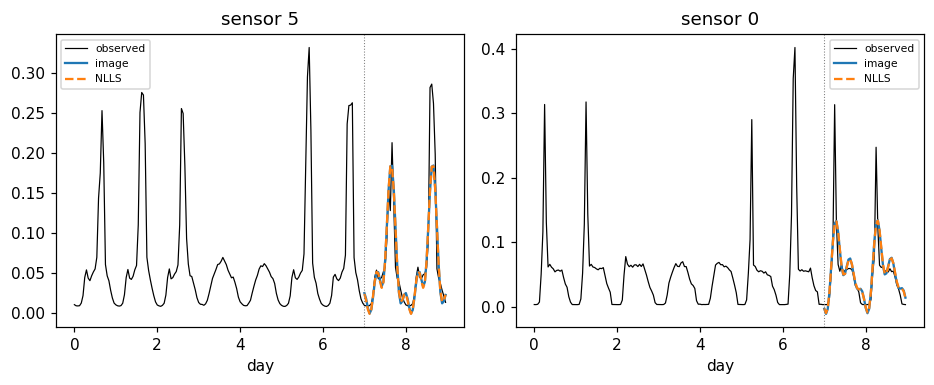

In [23]:
if traffic_nrmse.empty:
    print("traffic data missing, skipping the figure")
else:
    show = [s for s in ("5", "0") if s in traffic_results]
    fig, axes = plt.subplots(1, len(show), figsize=(8.6, 3.6))
    axes = np.atleast_1d(axes)
    for ax, s in zip(axes, show):
        r = traffic_results[s]
        seg = traffic_df[s].to_numpy(dtype=float)
        ax.plot(r["t"], seg, "k-", lw=0.8, label="observed")
        ax.plot(r["t"][r["k"]:], r["pred_img"][r["k"]:], "-", label="image")
        ax.plot(r["t"][r["k"]:], r["pred_nlls"][r["k"]:], "--", label="NLLS")
        ax.axvline(r["t"][r["k"]], color="grey", lw=0.7, ls=":")
        ax.set_title(f"sensor {s}")
        ax.set_xlabel("day")
        ax.legend(fontsize=7)
    fig.tight_layout()
    plt.show()


In [24]:
if traffic_nrmse.empty:
    print("traffic data missing, skipping the check")
else:
    med = traffic_nrmse[["image", "image_polished", "nlls"]].median()
    print(med.round(3).to_string())
    rel = abs(med["image"] - med["nlls"]) / med["nlls"] * 100
    print(f"image median is {rel:.2f}% relative to the NLLS median")
    # fails if the image median sits more than 5 percent from the NLLS median
    assert rel < 5.0
    for s, r in traffic_results.items():
        # fails if p0_image is built over names rather than sorted(names): dt.fit reads
        # a positional p0 in sorted name order, so w would take A1's seed value
        assert r["p0_image"] == [r["seed"][p] for p in r["names_fit"]], s
    print("every sensor's image fit was seeded in the fitter's own parameter order")
    if not QUICK:
        # fails if either median falls outside the 8-12 percent band measured on all 12
        # sensors; QUICK's four-sensor subset is not the same population
        assert 8.0 < med["image"] < 12.0
        assert 8.0 < med["nlls"] < 12.0


image             9.681
image_polished    9.687
nlls              9.687
image median is 0.05% relative to the NLLS median
every sensor's image fit was seeded in the fitter's own parameter order


## Findings and limits

Fitting the declared structure beats blind auto_forecast on every one of the four generated
waveforms by a wide margin (RLC transient 14.0x, AC harmonics 5.9x, AM signal 22.9x, chirp
25.6x): knowing the equation and only fitting its parameters is worth an order of magnitude
over a blind choice among the five classes the library routes between (logistic, linear,
linear_seasonal, poly, random_walk). On the eight measured series, where there is no equation
to know, the two routes sit close together: the declared
structure wins on four (USD/UAH, Mauna Loa CO2, ETTh1 oil-temp and the weather series), ties
to six figures on COVID-19 UA (2.954 both) and Nile flow (29.722 both, and poly extrapolation
lands on the same value), and loses on El Nino SST (13.15 against 12.68) and Sunspots (35.10
against 31.60). The structural knowledge is worth an order of magnitude where a governing
equation exists and close to nothing where one does not.

The declared structure is at or below random-walk persistence on 11 of the 12 series and
loses to it on exactly one, USD/UAH, a currency crash and partial recovery that a smooth
trend-plus-cycle form does not capture as well as yesterday's value does. The blind route
loses to random walk on four series (USD/UAH 205.4 against 50.9, the RLC transient 133.5
against 28.2, ETTh1 oil-temp 38.4 against 22.4, the weather series 80.6 against 78.1). Its
five classes hold no damped-oscillation and no crisis-recovery form: it produced the
quadratic level on the RLC transient and on USD/UAH, and the linear-plus-seasonal form on
the two LTSF series, each of them worse than repeating the last value.

The negative control holds on all three pairs tried: the wrong structure is worse in RMSE and
flagged by a lower in-sample R2 every time, most starkly on the chirp (right R2 0.9983,
wrong/poly R2 0.0442) and the RLC transient (right R2 0.9953, wrong/poly R2 0.1324). Fitting
the right equation is not a free improvement; it costs knowing the equation in the first place.

Against the published long-term-forecasting benchmark the inline trend-plus-seasonal
forecaster is not competitive, as claimed: at H=96 its MSE is 4.8x the best published number
on ETTh1, 5.0x on ETTm1 and 3.2x on weather, all comfortably past the 2x line the claim set.
The naive anchors scored on the same windows place that gap. Repeating the last observed row
scores 1.294 on ETTh1, 1.214 on ETTm1 and 0.259 on weather, so the trend and seasonal terms
this forecaster adds leave it 1.4x, 1.1x and 1.8x worse than doing nothing at all; repeating
the last whole day scores 0.512 on ETTh1 and 0.423 on ETTm1, against best published numbers
of 0.362 and 0.272 the forecaster is 4.8x and 5.0x away from. The loss is therefore a property of the
heuristic written in this notebook, which calls nothing from dtfit, and not a measurement of
the library.

The traffic result is the one true parity claim here: the image fit, the same fit polished by
a pointwise solve, and a plain pointwise fit from the same seed land within 0.05 percent of
each other (9.681 / 9.687 / 9.687 percent median nRMSE over twelve sensors), all inside 8 to
12 percent of the nine-day window's range. The image is not a weaker estimator on this real
record; it reaches the same optimum by a different route.

The extrapolation-distance reading is about the metric rather than the method (see above):
nRMSE as a percent of the holdout's own range can make a shorter holdout read as harder, when
that shorter slice sits on a quieter part of the record. The long holdout reads lower on
seven of the twelve series. A reader who wants "farther is harder" needs a metric normalized
by a fixed range, not the holdout's own.

Limits: the model-mismatch negative control was run on 3 of the 12 series, not all of them;
`auto_forecast`'s losses reflect the five model classes it currently routes among, not a
claim that no blind router could do better; the LTSF section measures a forecaster written
inline in this notebook against the published papers' own numbers, so it bounds neither the
library nor a rerun of DLinear, TimesNet or Time-LLM's actual code; no LSTM column runs here,
`torch` is not installed on this machine; and the traffic model is one declared structure (a
linear trend plus three fixed daily harmonics) on one nine-day window of twelve sensors, not
a swept alternative.

In [25]:
print(notebook.provenance(STARTED))


2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 41.4s
